<a href="https://colab.research.google.com/github/25WH1A0538/NASSCOM/blob/main/WEEK_3_U6_Probability_Statistics_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)


Setup complete. NumPy 2.1.3


In [3]:
rolls = np.random.randint(1, 7, size=100_000)

p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.499  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [4]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [5]:
import numpy as np

flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)
p_both_heads = np.mean(heads == 2)
print("P(both heads):", p_both_heads)


p_at_least_one = np.mean(heads >= 1)
print("P(at least one head):", p_at_least_one)


p_0 = np.mean(heads == 0)
p_1 = np.mean(heads == 1)
p_2 = np.mean(heads == 2)

total = p_0 + p_1 + p_2
print("P(0 heads):", p_0)
print("P(1 head):", p_1)
print("P(2 heads):", p_2)
print("Sum:", total)

P(both heads): 0.24936
P(at least one head): 0.75033
P(0 heads): 0.24967
P(1 head): 0.50097
P(2 heads): 0.24936
Sum: 1.0


In [6]:
rolls = np.random.randint(1, 7, size=100_000)

even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.333  (true 1/3)


In [7]:
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.501
P(A | B)  = 0.667
Independent? False


In [10]:
rolls = np.random.randint(1, 7, size=100_000)

condition = rolls < 4
p_odd_given_less4 = np.mean(rolls[condition] % 2 == 1)
print("P(odd | roll < 4):", p_odd_given_less4)

p_less4 = np.mean(rolls < 4)
print("P(roll < 4):", p_less4)

p_odd = np.mean(rolls % 2 == 1)
print("P(odd):", p_odd)

if np.isclose(p_odd_given_less4, p_odd, atol=0.01):
    print("The events are approximately independent.")
else:
    print("The events are not independent.")

P(odd | roll < 4): 0.6670333186672533
P(roll < 4): 0.50002
P(odd): 0.49954
The events are not independent.


In [11]:
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')


P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [12]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.508


In [13]:

p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham = 0.05

p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * (1 - p_spam))
print("P('free'):", p_free)

p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print("P(spam | 'free'):", p_spam_given_free)

P('free'): 0.16
P(spam | 'free'): 0.75


In [14]:
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')


Bernoulli(0.3) mean ~ 0.296 (true 0.3)
Poisson(4) mean ~ 3.981 (true 4)


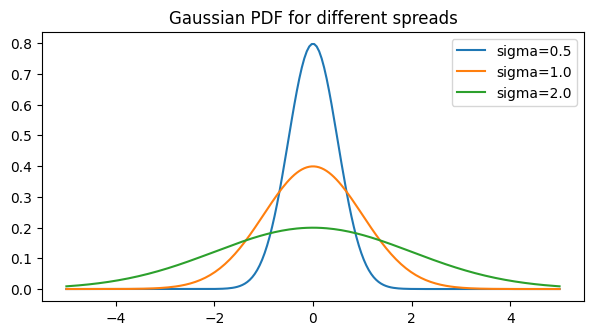

In [15]:
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Sample mean: 2.0046


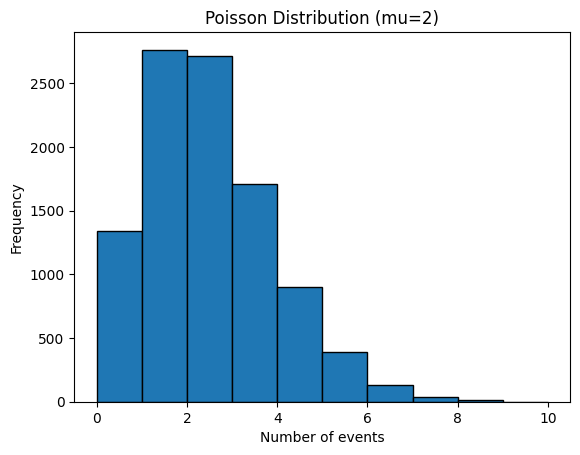

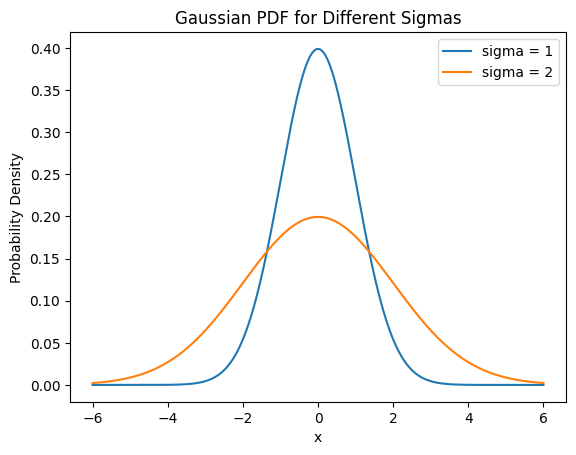

In [17]:
import numpy as np
import matplotlib.pyplot as plt

samples = np.random.poisson(lam=2, size=10_000)
print("Sample mean:", samples.mean())

plt.hist(samples, bins=range(0, max(samples) + 2), edgecolor="black")
plt.xlabel("Number of events")
plt.ylabel("Frequency")
plt.title("Poisson Distribution (mu=2)")
plt.show()

mu = 0
sigma1 = 1
sigma2 = 2
x = np.linspace(-6, 6, 1000)
pdf1 = (1 / (sigma1 * np.sqrt(2 * np.pi))) * np.exp(
    -((x - mu) ** 2) / (2 * sigma1 ** 2)
)
pdf2 = (1 / (sigma2 * np.sqrt(2 * np.pi))) * np.exp(
    -((x - mu) ** 2) / (2 * sigma2 ** 2)
)
plt.plot(x, pdf1, label="sigma = 1")
plt.plot(x, pdf2, label="sigma = 2")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Gaussian PDF for Different Sigmas")
plt.legend()
plt.show()

In [18]:
from scipy.stats import entropy
fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [19]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')


D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [20]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [21]:
import numpy as np
from scipy.stats import entropy
die4 = np.array([1/4] * 4)
die6 = np.array([1/6] * 6)
H4 = entropy(die4, base=2)
H6 = entropy(die6, base=2)
print("Entropy of 4-sided die:", H4, "bits")
print("Entropy of 6-sided die:", H6, "bits")
if H6 > H4:
    print("6-sided die is more uncertain.")
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])
KL = entropy(P, Q)
print("KL divergence D(P || Q):", KL)
print("Most informative: Petal length (cm)")
print("Least informative: Sepal width (cm)")

Entropy of 4-sided die: 2.0 bits
Entropy of 6-sided die: 2.584962500721156 bits
6-sided die is more uncertain.
KL divergence D(P || Q): 0.08228287850505175
Most informative: Petal length (cm)
Least informative: Sepal width (cm)
